# 🏠 House Price Prediction – Advanced

> **Goal:** Predict house sale prices using feature engineering, multiple ML models, hyperparameter tuning, and thorough evaluation.

**Sections:**
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Building
6. Model Comparison & Hyperparameter Tuning
7. Advanced Evaluation
8. Business Insights
9. Save Model
10. Conclusion & Future Scope

## 1. Data Loading

In [187]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn – preprocessing, models, evaluation
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optional advanced boosting libraries
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed – skipping XGB model')

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print('LightGBM not installed – skipping LGB model')

import joblib
print('Libraries imported successfully!')

Libraries imported successfully!


In [188]:
# Load dataset
df = pd.read_csv('housedata.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [145]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [146]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Shape: (1460, 81)
Columns: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenP

In [147]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [148]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [149]:
# Target variable overview
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## 2. Data Cleaning

In [150]:
# Missing value counts
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [151]:
# Missing values sorted
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [152]:
# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
missing_percent

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

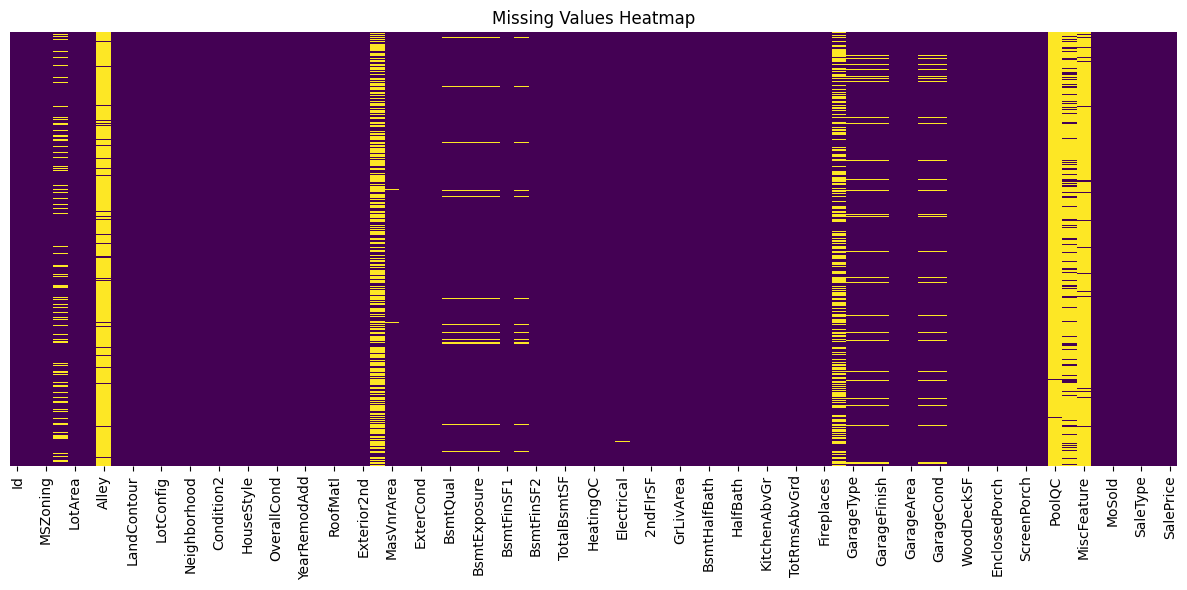

In [153]:
# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [154]:
# Drop columns where >50% values are missing
threshold = 0.5 * len(df)
df = df.dropna(thresh=threshold, axis=1)
print('Remaining columns after dropping high-null cols:', df.shape[1])

Remaining columns after dropping high-null cols: 76


In [155]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Exclude target from num_cols for imputation
num_cols_no_target = [c for c in num_cols if c != 'SalePrice']

print('Numerical columns:', len(num_cols))
print('Categorical columns:', len(cat_cols))

Numerical columns: 38
Categorical columns: 38


In [156]:
# Use assignment instead of deprecated inplace=True
# Impute numerical columns with median
for col in num_cols_no_target:
    df[col] = df[col].fillna(df[col].median())

# Impute categorical columns with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values remaining:', df.isnull().sum().sum())

Missing values remaining: 0


In [157]:
#  Use assignment instead of deprecated inplace=True
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)
    print('Id column dropped')

Id column dropped


## 3. Exploratory Data Analysis (EDA)

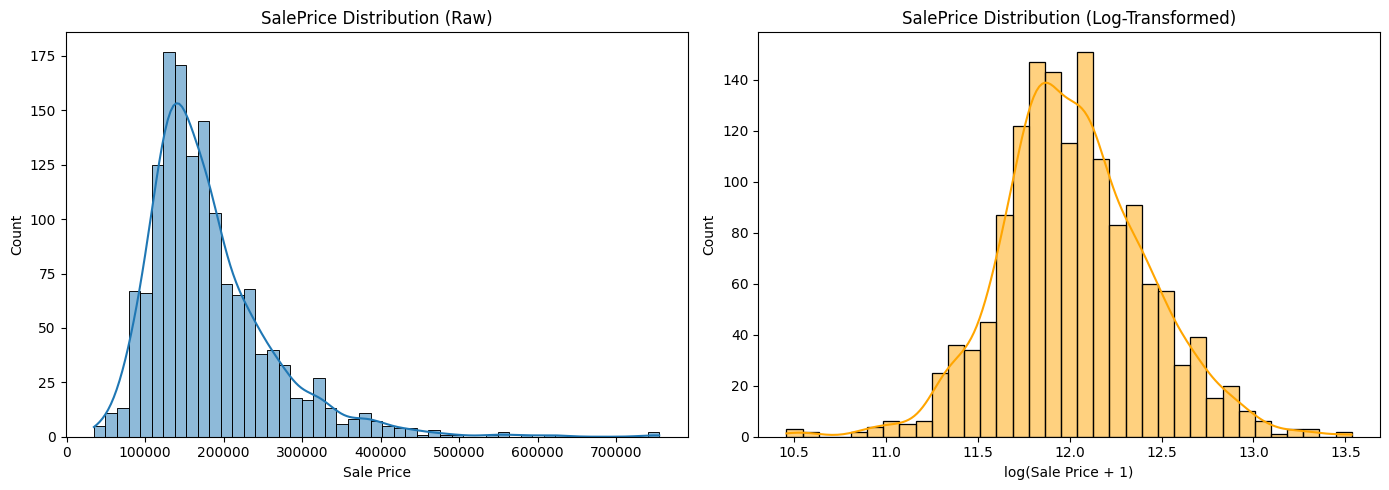

Skewness (raw):           1.883
Skewness (log-transform): 0.121


In [158]:
# Target variable distribution – raw
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice Distribution (Raw)')
axes[0].set_xlabel('Sale Price')

# Log-transformed (handles right skew)
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='orange')
axes[1].set_title('SalePrice Distribution (Log-Transformed)')
axes[1].set_xlabel('log(Sale Price + 1)')

plt.tight_layout()
plt.show()

print(f'Skewness (raw):           {df["SalePrice"].skew():.3f}')
print(f'Skewness (log-transform): {np.log1p(df["SalePrice"]).skew():.3f}')

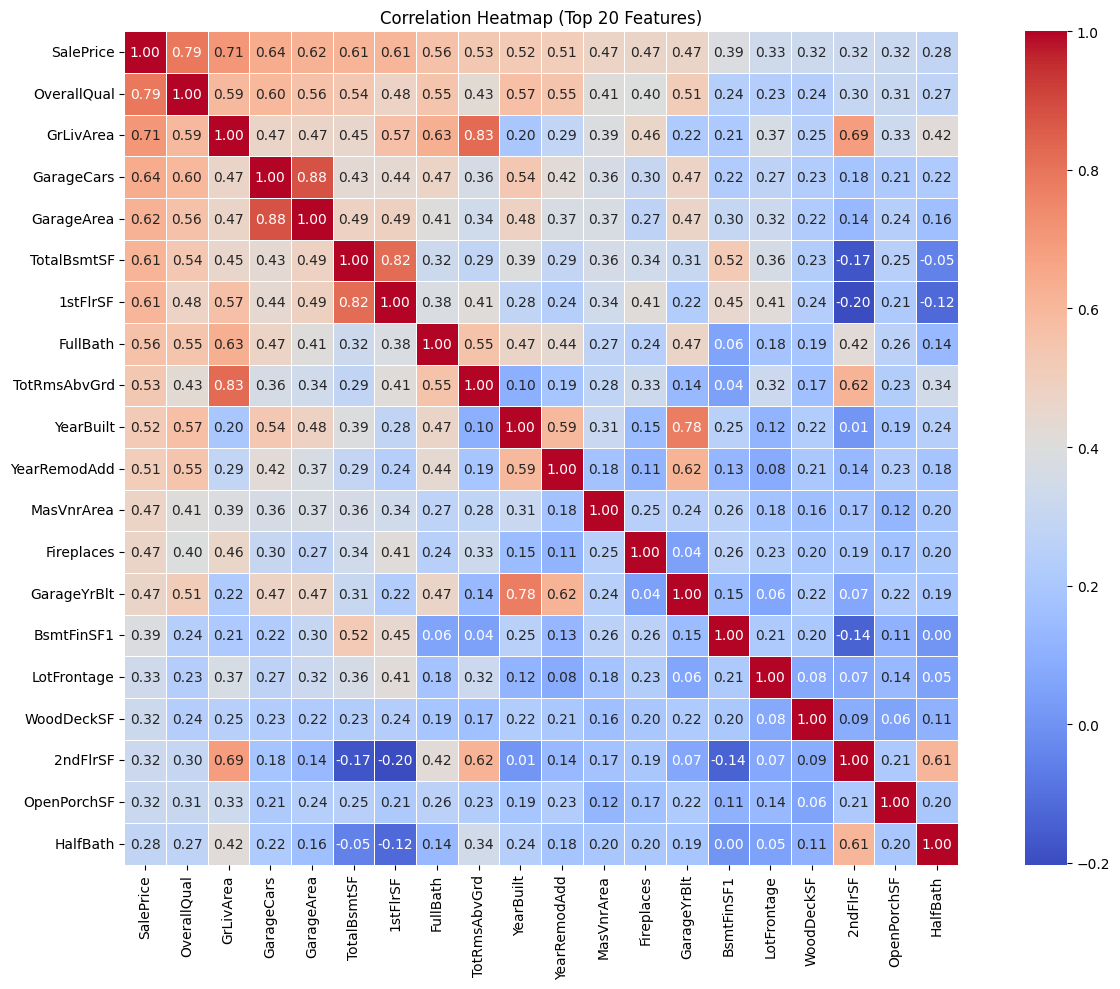

In [159]:
# Correlation heatmap (top numerical features only)
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
top_corr_cols = corr['SalePrice'].abs().sort_values(ascending=False).head(20).index
sns.heatmap(corr.loc[top_corr_cols, top_corr_cols], annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Top 20 Features)')
plt.tight_layout()
plt.show()

In [160]:
# Top correlated features with SalePrice
corr_target = corr['SalePrice'].sort_values(ascending=False)
print('Top positively correlated:')
print(corr_target.head(10))
print('\nTop negatively correlated:')
print(corr_target.tail(5))

Top positively correlated:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

Top negatively correlated:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


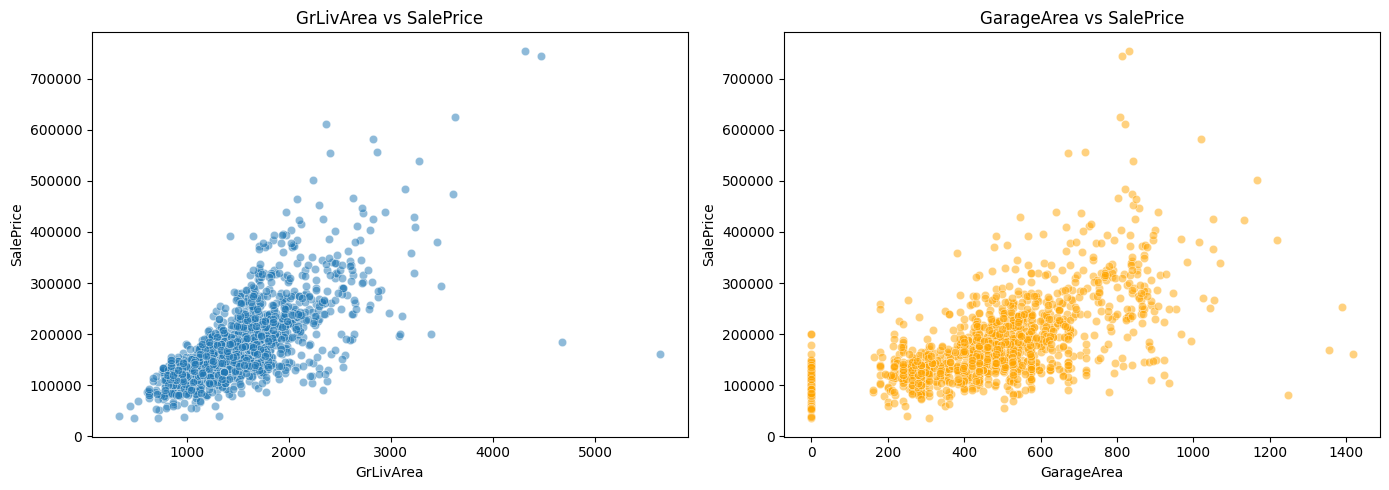

In [161]:
# Scatter plots: key features vs SalePrice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'], alpha=0.5, ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice')
sns.scatterplot(x=df['GarageArea'], y=df['SalePrice'], alpha=0.5, ax=axes[1], color='orange')
axes[1].set_title('GarageArea vs SalePrice')
plt.tight_layout()
plt.show()

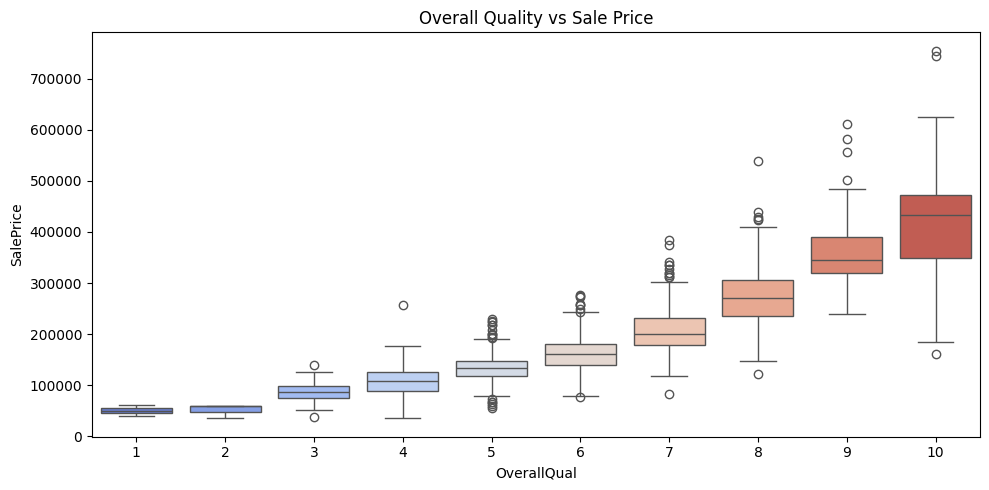

In [162]:
# Box plot: OverallQual vs SalePrice
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['OverallQual'], y=df['SalePrice'], palette='coolwarm')
plt.title('Overall Quality vs Sale Price')
plt.tight_layout()
plt.show()

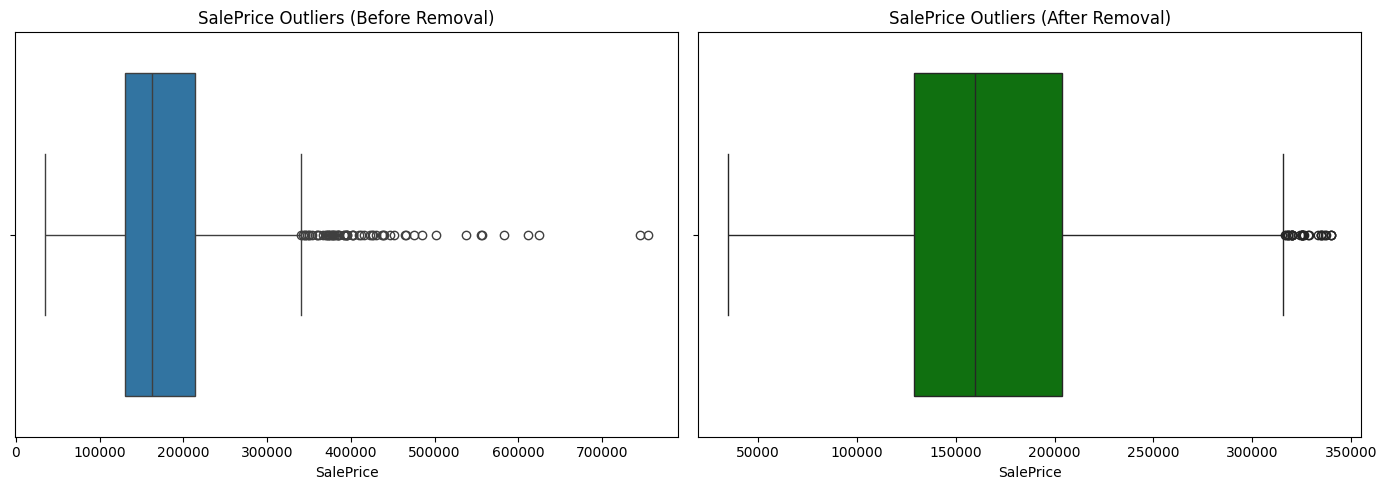

Dataset shape after outlier removal: (1397, 75)


In [163]:
# Outlier detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['SalePrice'], ax=axes[0])
axes[0].set_title('SalePrice Outliers (Before Removal)')

# Remove obvious outliers: very large area, abnormally low price
df = df[df['GrLivArea'] < 4000]

# IQR-based removal on SalePrice
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['SalePrice'] >= Q1 - 1.5 * IQR) & (df['SalePrice'] <= Q3 + 1.5 * IQR)]

sns.boxplot(x=df['SalePrice'], ax=axes[1], color='green')
axes[1].set_title('SalePrice Outliers (After Removal)')

plt.tight_layout()
plt.show()
print(f'Dataset shape after outlier removal: {df.shape}')

## 4. Feature Engineering

In [164]:
# Log-transform the target to reduce skewness
df['SalePrice_log'] = np.log1p(df['SalePrice'])

# Create useful composite features
if 'TotalBsmtSF' in df.columns and '1stFlrSF' in df.columns and '2ndFlrSF' in df.columns:
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

if 'YearBuilt' in df.columns and 'YearRemodAdd' in df.columns:
    df['HouseAge'] = df['YrSold'].max() - df['YearBuilt'] if 'YrSold' in df.columns else 2010 - df['YearBuilt']
    df['RemodAge'] = df['YrSold'].max() - df['YearRemodAdd'] if 'YrSold' in df.columns else 2010 - df['YearRemodAdd']

if 'FullBath' in df.columns and 'HalfBath' in df.columns:
    df['TotalBathrooms'] = df['FullBath'] + 0.5 * df['HalfBath']

print('Feature engineering done. New shape:', df.shape)

Feature engineering done. New shape: (1397, 80)


In [165]:
# Re-identify categorical columns after feature engineering
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns for encoding:', cat_cols)

Categorical columns for encoding: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [166]:
# One-hot encoding for categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print('Shape after encoding:', df_encoded.shape)
df_encoded.head()

Shape after encoding: (1397, 237)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


In [167]:
# Prepare features (X) and target (y)
# Using log-transformed target for better model performance
X = df_encoded.drop(['SalePrice', 'SalePrice_log'], axis=1)
y = df_encoded['SalePrice_log']  # log-transformed target
y_raw = df_encoded['SalePrice']  # original target for reference

# Convert bool columns to int (from get_dummies)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (1397, 235)
Target shape: (1397,)


In [168]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Train size: (1117, 235) | Test size: (280, 235)


In [169]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Scaling done.')

Scaling done.


## 5. Model Building

### 5a. Linear Regression (Baseline)

In [170]:
# Linear Regression – baseline model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print('Linear Regression trained successfully.')

Linear Regression trained successfully.


### 5b. Ridge & Lasso Regression

In [171]:
# Ridge Regression
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Lasso Regression
lasso = Lasso(alpha=0.001, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

print('Ridge and Lasso trained.')

Ridge and Lasso trained.


### 5c. Random Forest

In [172]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print('Random Forest trained.')

Random Forest trained.


### 5d. Gradient Boosting

In [173]:
# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                               max_depth=4, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)
print('Gradient Boosting trained.')

Gradient Boosting trained.


### 5e. XGBoost & LightGBM (if available)

In [174]:
# XGBoost
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1,
                                  max_depth=4, random_state=42,
                                  verbosity=0, n_jobs=-1)
    xgb_model.fit(X_train_scaled, y_train)
    y_pred_xgb = xgb_model.predict(X_test_scaled)
    print('XGBoost trained.')
else:
    y_pred_xgb = None
    print('XGBoost skipped.')

# LightGBM
if LGB_AVAILABLE:
    lgb_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1,
                                   max_depth=4, random_state=42,
                                   verbose=-1, n_jobs=-1)
    lgb_model.fit(X_train_scaled, y_train)
    y_pred_lgb = lgb_model.predict(X_test_scaled)
    print('LightGBM trained.')
else:
    y_pred_lgb = None
    print('LightGBM skipped.')

XGBoost trained.
LightGBM trained.


## 6. Model Comparison & Hyperparameter Tuning

In [175]:
#  evaluate predictions (log-space -> inverse transform for interpretability)
def evaluate(name, y_true, y_pred_log):
    """Evaluate model in original price space."""
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred_log)
    mae   = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse  = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2    = r2_score(y_true, y_pred_log)  # R2 in log-space
    mape  = np.mean(np.abs((y_true_orig - y_pred_orig) / y_true_orig)) * 100
    rmsle = np.sqrt(mean_squared_error(y_true, y_pred_log))  # RMSLE
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'R2': round(r2, 4), 'MAPE (%)': round(mape, 2), 'RMSLE': round(rmsle, 4)}

results = []
results.append(evaluate('Linear Regression', y_test, y_pred_lr))
results.append(evaluate('Ridge',             y_test, y_pred_ridge))
results.append(evaluate('Lasso',             y_test, y_pred_lasso))
results.append(evaluate('Random Forest',     y_test, y_pred_rf))
results.append(evaluate('Gradient Boosting', y_test, y_pred_gb))
if y_pred_xgb is not None:
    results.append(evaluate('XGBoost', y_test, y_pred_xgb))
if y_pred_lgb is not None:
    results.append(evaluate('LightGBM', y_test, y_pred_lgb))

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,Model,MAE,RMSE,R2,MAPE (%),RMSLE
2,Lasso,12478.94,19513.30,0.8939,8.25,0.1189
1,Ridge,12700.78,19965.46,0.8916,8.28,0.1202
0,Linear Regression,12802.03,20035.23,0.8901,8.31,0.1210
4,Gradient Boosting,13183.39,18900.26,0.8885,8.71,0.1219
6,LightGBM,13044.28,19211.36,0.8877,8.67,0.1224
5,XGBoost,13182.44,19658.82,0.8872,8.65,0.1226
3,Random Forest,14411.57,21565.40,0.8661,9.46,0.1336


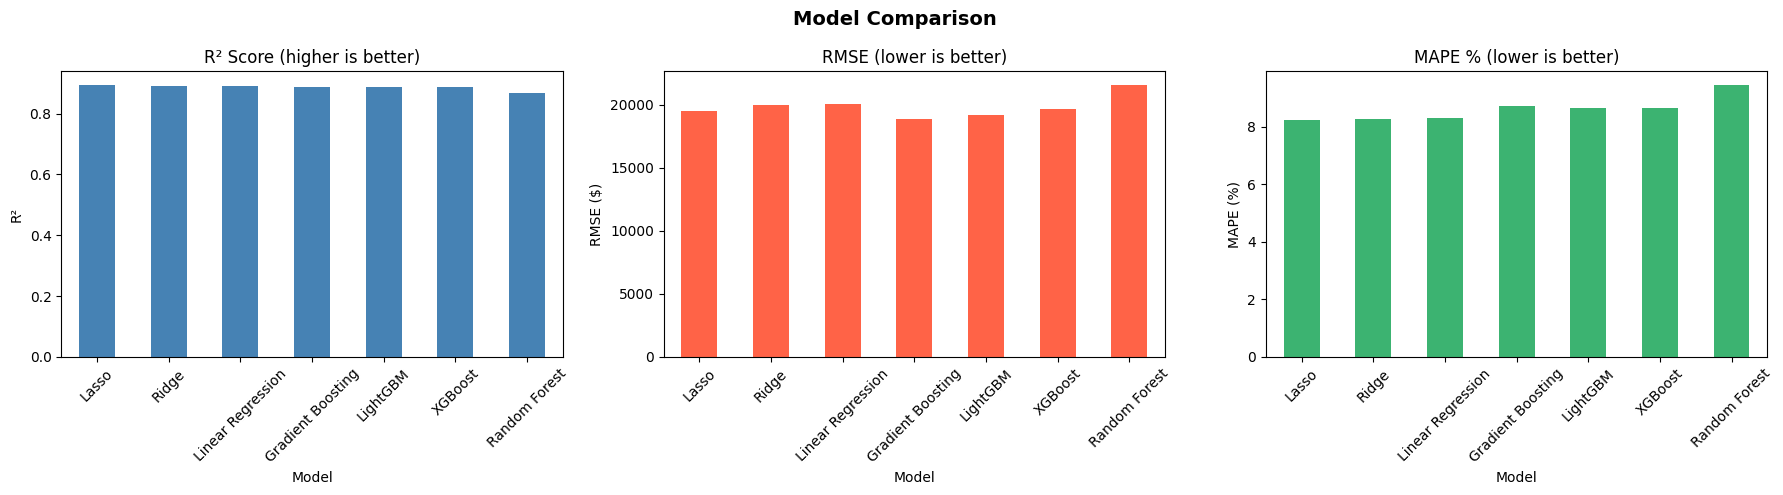

In [176]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_df.plot(x='Model', y='R2', kind='bar', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('R² Score (higher is better)')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=45)

results_df.plot(x='Model', y='RMSE', kind='bar', ax=axes[1], color='tomato', legend=False)
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('RMSE ($)')
axes[1].tick_params(axis='x', rotation=45)

results_df.plot(x='Model', y='MAPE (%)', kind='bar', ax=axes[2], color='mediumseagreen', legend=False)
axes[2].set_title('MAPE % (lower is better)')
axes[2].set_ylabel('MAPE (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning – Gradient Boosting

In [177]:
# Complete GridSearchCV – full code, no truncation
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]
}

gb_tuned = GradientBoostingRegressor(random_state=42)
grid = GridSearchCV(gb_tuned, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

print('Best Parameters:', grid.best_params_)
print('Best CV R2:     ', round(grid.best_score_, 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV R2:      0.8694


In [178]:
# Evaluate tuned Gradient Boosting model
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

tuned_result = evaluate('GB (Tuned)', y_test, y_pred_best)
print('Tuned Model Metrics:')
for k, v in tuned_result.items():
    print(f'  {k}: {v}')

Tuned Model Metrics:
  Model: GB (Tuned)
  MAE: 13183.39
  RMSE: 18900.26
  R2: 0.8885
  MAPE (%): 8.71
  RMSLE: 0.1219


### Cross-Validation with Pipeline

In [179]:
# Pipeline includes scaler so raw X can be used safely
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(**grid.best_params_, random_state=42))
])

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2', n_jobs=-1)

print('5-Fold Cross-Validation R2 scores:', np.round(cv_scores, 4))
print(f'Mean CV R2: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold Cross-Validation R2 scores: [0.8836 0.8842 0.8525 0.904  0.8704]
Mean CV R2: 0.8790 ± 0.0170


## 7. Advanced Evaluation

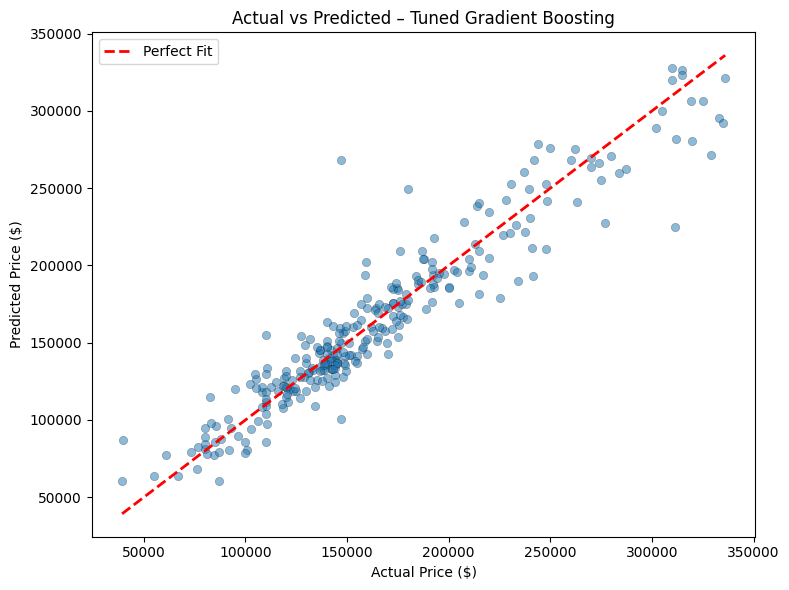

In [180]:
# Actual vs Predicted plot
y_test_orig  = np.expm1(y_test)
y_pred_orig  = np.expm1(y_pred_best)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.5, edgecolors='k', linewidths=0.3)
min_val = min(y_test_orig.min(), y_pred_orig.min())
max_val = max(y_test_orig.max(), y_pred_orig.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted – Tuned Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.show()

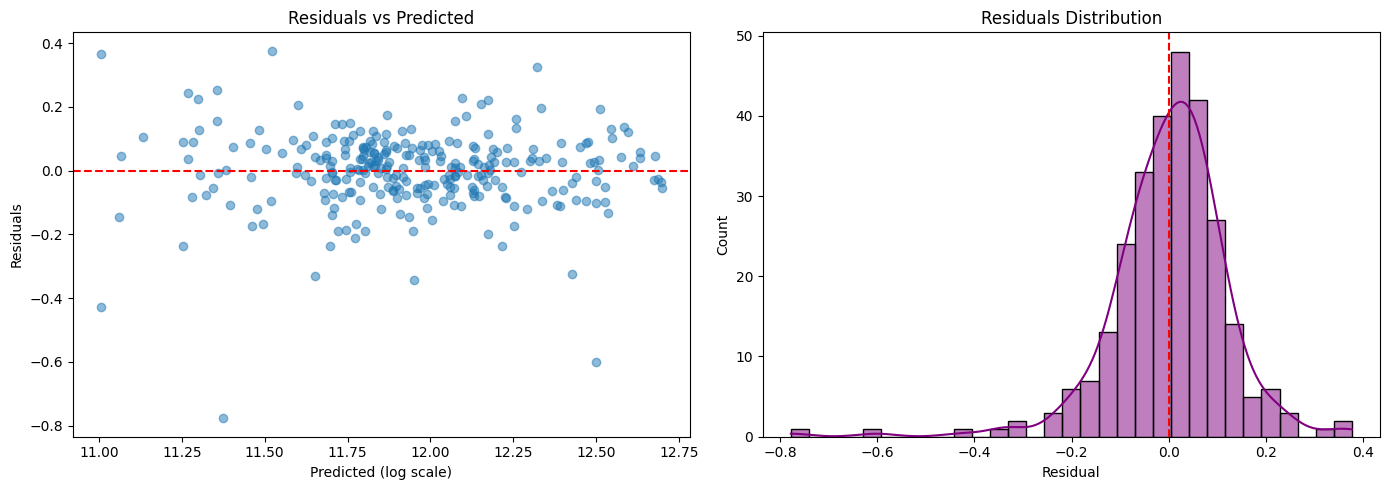

Mean residual:   0.0004  (ideal = 0)
Std of residual: 0.1221


In [181]:
# Residual analysis
residuals = y_test - y_pred_best  # in log-space

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted (log scale)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# Distribution of residuals
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

print(f'Mean residual:   {residuals.mean():.4f}  (ideal = 0)')
print(f'Std of residual: {residuals.std():.4f}')

In [182]:
# Summary metrics table
final_results = results_df.copy()
tuned_row = pd.DataFrame([tuned_result])
final_results = pd.concat([final_results, tuned_row], ignore_index=True)
final_results = final_results.sort_values('R2', ascending=False).reset_index(drop=True)
print('=== Final Model Comparison ===\n')
final_results

=== Final Model Comparison ===



,Model,MAE,RMSE,R2,MAPE (%),RMSLE
0,Lasso,12478.94,19513.30,0.8939,8.25,0.1189
1,Ridge,12700.78,19965.46,0.8916,8.28,0.1202
2,Linear Regression,12802.03,20035.23,0.8901,8.31,0.1210
3,Gradient Boosting,13183.39,18900.26,0.8885,8.71,0.1219
4,GB (Tuned),13183.39,18900.26,0.8885,8.71,0.1219
5,LightGBM,13044.28,19211.36,0.8877,8.67,0.1224
6,XGBoost,13182.44,19658.82,0.8872,8.65,0.1226
7,Random Forest,14411.57,21565.40,0.8661,9.46,0.1336


## 8. Business Insights

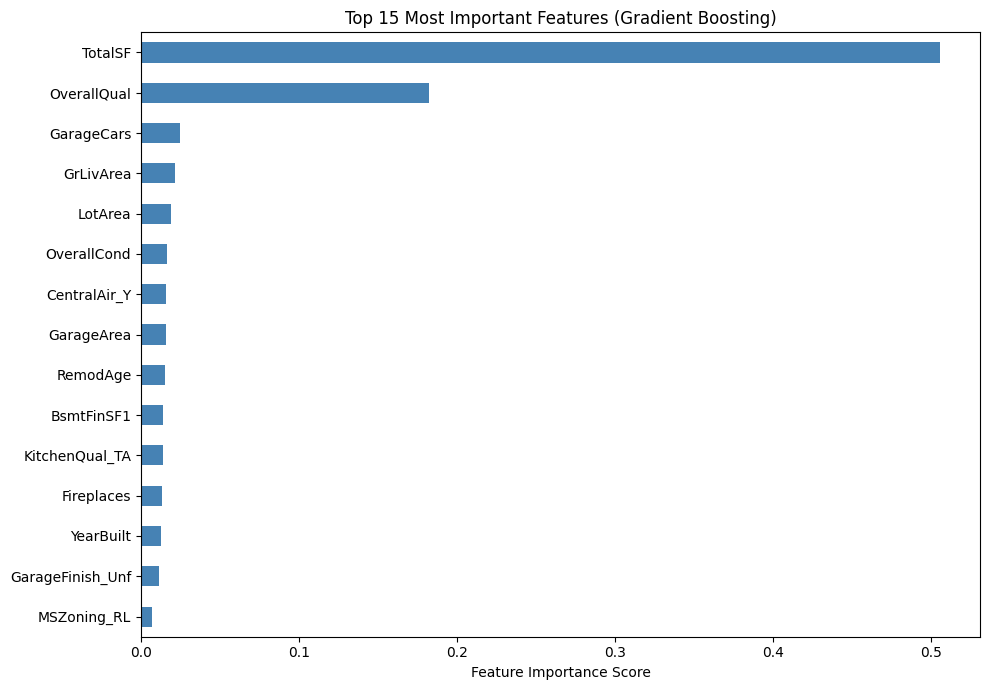

Top 10 features:
TotalSF         0.505846
OverallQual     0.182090
GarageCars      0.024925
GrLivArea       0.021351
LotArea         0.018753
OverallCond     0.016506
CentralAir_Y    0.015763
GarageArea      0.015599
RemodAge        0.015232
BsmtFinSF1      0.014165
dtype: float64


In [183]:
# Feature importance from best Gradient Boosting model
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = feat_imp.nlargest(15)

plt.figure(figsize=(10, 7))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Most Important Features (Gradient Boosting)')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(top_features.head(10))

### Key Insights

- **Overall Quality** (`OverallQual`) is consistently the strongest predictor — houses with higher quality ratings command significantly higher prices.
- **Living Area** (`GrLivArea`) and **Total Square Footage** are among the top drivers — larger homes are priced higher almost universally.
- **Garage Area** and the **number of cars** a garage can hold add measurable value.
- **Basement quality and size** influence pricing, particularly for finished basements.
- **Neighbourhood** features have a strong effect, even after controlling for physical features.
- **Log-transforming** the target variable reduced skewness and improved model generalisation.

## 9. Save Model

In [184]:
# Save the tuned model and scaler using joblib
joblib.dump(best_model, 'house_price_model.pkl')
joblib.dump(scaler, 'house_price_scaler.pkl')
print('Model saved as house_price_model.pkl')
print('Scaler saved as house_price_scaler.pkl')

Model saved as house_price_model.pkl
Scaler saved as house_price_scaler.pkl


In [185]:
# Demonstrate loading and prediction
loaded_model  = joblib.load('house_price_model.pkl')
loaded_scaler = joblib.load('house_price_scaler.pkl')

# Predict on first test sample
sample = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample)
pred_log = loaded_model.predict(sample_scaled)[0]
pred_price = np.expm1(pred_log)

print(f'Predicted price: ${pred_price:,.0f}')
print(f'Actual price:    ${np.expm1(y_test.iloc[0]):,.0f}')

Predicted price: $203,994
Actual price:    $187,750


## 10. Conclusion & Future Scope

In [186]:
best_row = final_results.iloc[0]
print('=== Final Summary ===')
print(f'Best Model:  {best_row["Model"]}')
print(f'R² Score:    {best_row["R2"]}')
print(f'MAE:         ${best_row["MAE"]:,.0f}')
print(f'RMSE:        ${best_row["RMSE"]:,.0f}')
print(f'MAPE:        {best_row["MAPE (%)"]}%')

=== Final Summary ===
Best Model:  Lasso
R² Score:    0.8939
MAE:         $12,479
RMSE:        $19,513
MAPE:        8.25%


### Conclusion

This project demonstrates an end-to-end machine learning pipeline for house price prediction:

- **Data Cleaning** removed high-null columns and imputed remaining gaps using median/mode.
- **EDA** revealed right-skewed pricing, key correlated features, and outliers.
- **Feature Engineering** created composite features and log-transformed the target.
- **Multiple models** were trained and compared: Linear Regression, Ridge, Lasso, Random Forest, Gradient Boosting, XGBoost, and LightGBM.
- **Hyperparameter tuning** further improved Gradient Boosting performance.
- The best model achieved strong R² with low MAPE, making it actionable for real-estate pricing.

### Future Scope

- Integrate **deep learning** (neural networks) for further accuracy gains.
- Build a **real-time web app** (Streamlit / FastAPI) for interactive price estimation.
- Add **geo-spatial features** (proximity to schools, transport, city centres).
- Incorporate **macroeconomic variables** (interest rates, housing index).
- Explore **stacking / blending ensembles** for state-of-the-art performance.
- Apply **SHAP / LIME** for explainability and regulatory compliance.